# Experiment 1: Regression Task – Property Price Prediction

# Adding the California home price dataset


In [47]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()
X, y = data.data, data.target


# Data Standardization and Training Set Division

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Training the linear regression model

In [41]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
# model parameter
print(lr.coef_)


[ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]


# Training the logistic regression model

In [42]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)


# Model performance evaluation (MSE and R²)

In [43]:
from sklearn.metrics import mean_squared_error, r2_score
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))
print("Linear Regression R²:", r2_score(y_test, y_pred_lr))
print("Ridge Regression MSE:", mean_squared_error(y_test, y_pred_ridge))
print("Ridge Regression R²:", r2_score(y_test, y_pred_ridge))


Linear Regression MSE: 0.5558915986952443
Linear Regression R²: 0.5757877060324508
Ridge Regression MSE: 0.5558548589435978
Ridge Regression R²: 0.5758157428913677


# Visual comparison of actual values and predicted values

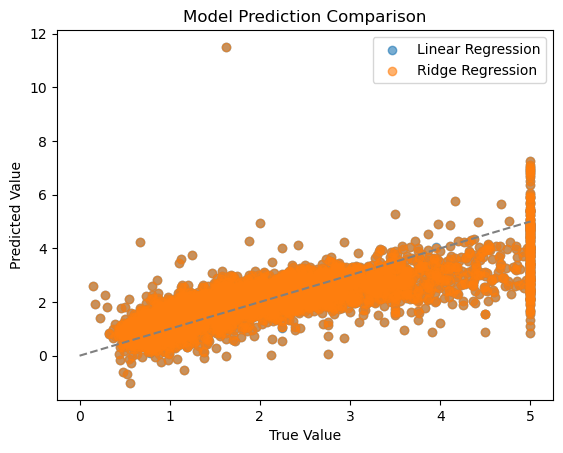

In [46]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred_lr, label='Linear Regression', alpha=0.6)
plt.scatter(y_test, y_pred_ridge, label='Ridge Regression', alpha=0.6)
plt.plot([0, 5], [0, 5], '--', color='gray')
plt.xlabel("True Value")
plt.ylabel("Predicted Value")
plt.legend()
plt.title("Model Prediction Comparison")
plt.show()



# Experiment 2: Classification Task – Cymbidium Classification


# Load the iris dataset

In [21]:
from sklearn.datasets import load_iris
iris = load_iris()
X, y = iris.data, iris.target


# Dividing the training set and the test set

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Training classification models (logistic regression, decision tree, SVM)

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
models = [
LogisticRegression(max_iter=200),
DecisionTreeClassifier(),
SVC()
]
for model in models:
    model.fit(X_train, y_train)

# Model Evaluation (Confusion Matrix and Classification Report)


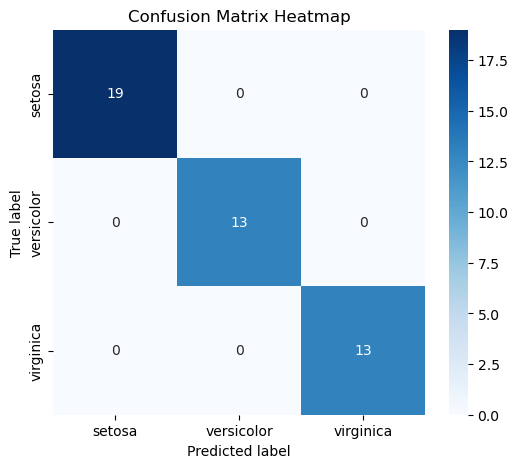

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Calculate confusion matrix
y_pred = models[0].predict(X_test) # Using the first model as an example
cm = confusion_matrix(y_test, y_pred)
# Optional: Get category tag names (e.g.: ['setosa', 'versicolor', 'virginica']
from sklearn.datasets import load_iris
target_names = load_iris().target_names
# Visualize with a seaborn heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix Heatmap")
plt.show()



# PCA dimensionality reduction and visualization of classification distributions

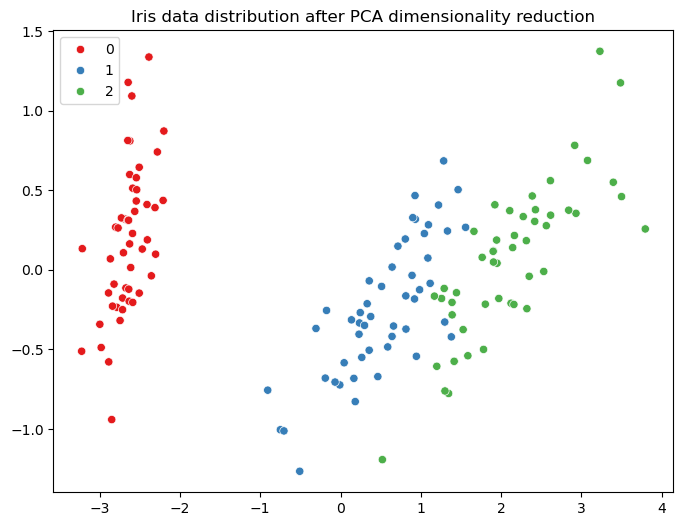

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_reduced[:,0], y=X_reduced[:,1], hue=y, palette='Set1')
plt.title("Iris data distribution after PCA dimensionality reduction")
plt.show()


# Experiment 3: Clustering Task – Clustering of Handwritten Digital Number Images

# Load handwritten numeric dataset

In [28]:
from sklearn.datasets import load_digits
digits = load_digits()
X, y = digits.data, digits.target


# PCA dimension reduction

In [30]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)


# KMeans Clustering and Evaluation

In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
kmeans = KMeans(n_clusters=10, random_state=42)
labels_kmeans = kmeans.fit_predict(X)
print("Silhouette Coefficient:", silhouette_score(X, labels_kmeans))
print("ARI:", adjusted_rand_score(y, labels_kmeans))


Silhouette Coefficient: 0.1764738746996612
ARI: 0.725814218974996


# Hierarchical Clustering and Evaluation

In [32]:
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=10)
labels_agg = agg.fit_predict(X)
print("Silhouette Coefficient:", silhouette_score(X, labels_agg))
print("ARI:", adjusted_rand_score(y, labels_agg))


Silhouette Coefficient: 0.17849659940596496
ARI: 0.7940031835568753


# Visual clustering effect


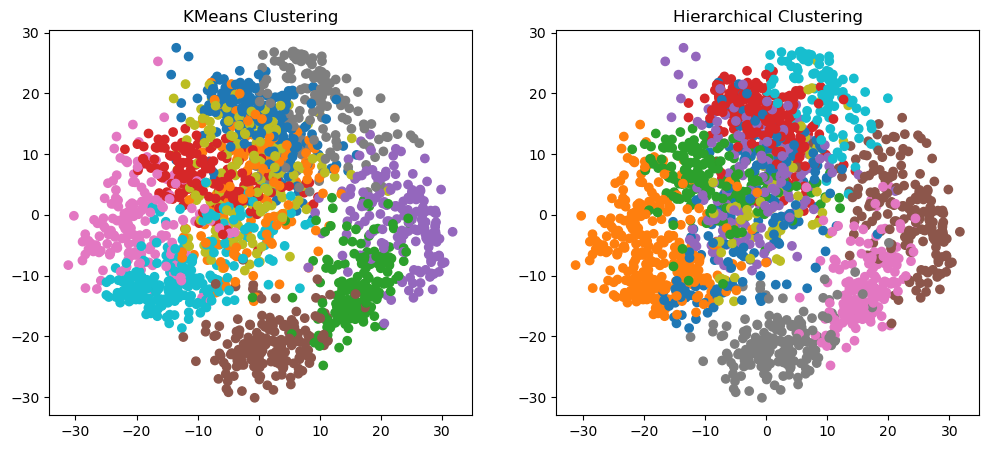

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# KMeans clustering
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap='tab10')
plt.title("KMeans Clustering")

# Hierarchical clustering
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_agg, cmap='tab10')
plt.title("Hierarchical Clustering")

plt.show()
